In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [21]:
# Now let use see why linear regression fails for Logisic REGERESSION to begin with

In [22]:
# 1. Create dataset
df = pd.DataFrame({
    'size':[1,2,3,5,6,8],
    'malignant': [0, 0, 0, 1, 1, 1]
})

In [23]:
# 2. Fit Linear Regression
X = df[['size']]
y = df['malignant']
model = LinearRegression()
model.fit(X, y)

# 3. Add predictions and threshold outputs to DataFrame
df['y_hat'] = model.predict(X)
df['prediction'] = (df['y_hat'] >= 0.5).astype(int)


df


,size,malignant,y_hat,prediction
0,1,0,-0.090909,0
1,2,0,0.095694,0
2,3,0,0.282297,0
3,5,1,0.655502,1
4,6,1,0.842105,1
5,8,1,1.215311,1


In [24]:
# 4. Separate classes for plotting
benign = df[df['malignant'] == 0]
malignant = df[df['malignant'] == 1]

c:\Users\hp\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


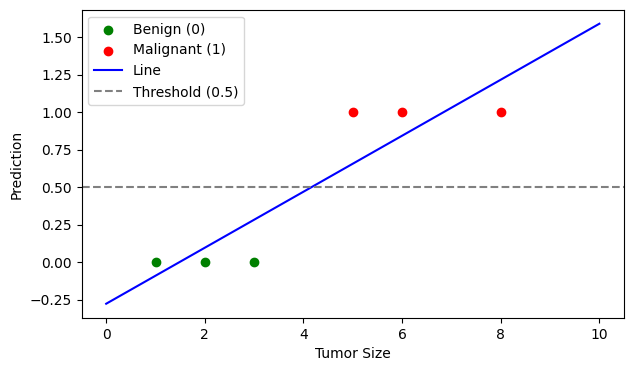

In [25]:
# 5. Simple Plot
plt.figure(figsize=(7, 4))

# Plot different classes with colors
plt.scatter(benign['size'], benign['malignant'], color='green', label='Benign (0)')
plt.scatter(malignant['size'], malignant['malignant'], color='red', label='Malignant (1)')

# Generate points to draw the regression line
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = model.predict(x_line)

# Plot regression line and 0.5 threshold
plt.plot(x_line, y_line, color='blue', label='Line')
plt.axhline(0.5, color='gray', linestyle='--', label='Threshold (0.5)')

# Layout details
plt.xlabel('Tumor Size')
plt.ylabel('Prediction')
plt.legend()
plt.show()

In [ ]:
# This idea is never possible to be honest because the prediction is not probabilities to begin with.
# We are using linear regression and it's job is to fit the data points not classify them , it does not know how to .
# What it does is just try to capture as much variance as possible .

# Also if we look closely at our y_hat ( predictions ) : They range from -inf to +inf
# This is problematic because probabilites are in the range 0 to 1 and not in this range

# If we want to use this function we have to bridge somehow a way between these ranges by comparing with a new equation through
# which we will be able to convert any number to a probability's axiom and vice versa.


In [31]:
# ==========================================
# PART 2 MODIFICATION: THE MSE DEFECT DEMO
# ==========================================

# 1. Append the malignant outlier (size 20) to your existing dataframe
df_outlier = pd.concat([df[['size', 'malignant']], pd.DataFrame({'size':[20], 'malignant': [1]})], ignore_index=True)

# 2. Refit the Linear Regression model on this expanded dataset
X_outlier = df_outlier[['size']]
y_outlier = df_outlier['malignant']
model_outlier = LinearRegression()
model_outlier.fit(X_outlier, y_outlier)

# 3. Compute new continuous predictions and the 0.5 threshold classifications
df_outlier['y_hat_new'] = model_outlier.predict(X_outlier)
df_outlier['prediction_new'] = (df_outlier['y_hat_new'] >= 0.5).astype(int)

# 4. Calculate the quadratic penalty to show how the outlier is punished for being "too right"
df_outlier['squared_error'] = (df_outlier['malignant'] - df_outlier['y_hat_new']) ** 2

c:\Users\hp\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


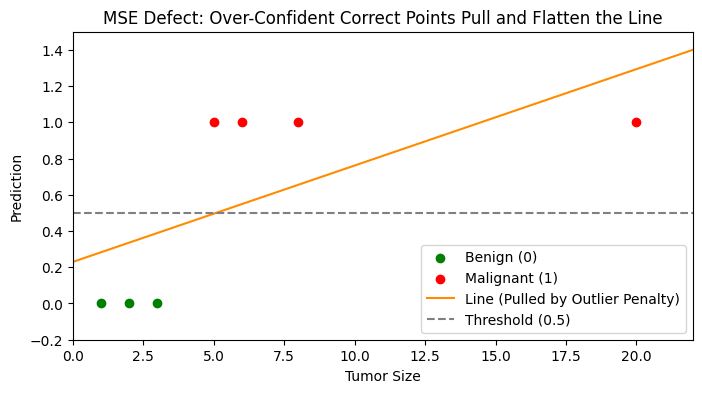

In [30]:
# 5. Separate updated classes for plotting
benign_outlier = df_outlier[df_outlier['malignant'] == 0]
malignant_outlier = df_outlier[df_outlier['malignant'] == 1]

# 6. Plotting the failure scenario
plt.figure(figsize=(8, 4))

# Plot the points (notice size 5 is now misclassified below the threshold line)
plt.scatter(benign_outlier['size'], benign_outlier['malignant'], color='green', label='Benign (0)')
plt.scatter(malignant_outlier['size'], malignant_outlier['malignant'], color='red', label='Malignant (1)')

# Generate a wider line range to fit the outlier point at x=20
x_line_outlier = np.linspace(0, 22, 100).reshape(-1, 1)
y_line_outlier = model_outlier.predict(x_line_outlier)

# Plot the new regression line and the decision boundary
plt.plot(x_line_outlier, y_line_outlier, color='darkorange', label='Line (Pulled by Outlier Penalty)')
plt.axhline(0.5, color='gray', linestyle='--', label='Threshold (0.5)')

# Layout tweaks
plt.xlabel('Tumor Size')
plt.ylabel('Prediction')
plt.xlim(0, 22)
plt.ylim(-0.2, 1.5)
plt.title('MSE Defect: Over-Confident Correct Points Pull and Flatten the Line')
plt.legend()
plt.show()


In [32]:
df_outlier

,size,malignant,y_hat_new,prediction_new,squared_error
0,1,0,0.282609,0,0.079868
1,2,0,0.335812,0,0.112770
2,3,0,0.389016,0,0.151333
3,5,1,0.495423,0,0.254598
4,6,1,0.548627,1,0.203738
5,8,1,0.655034,1,0.119001
6,20,1,1.293478,1,0.086129


In [33]:
# If you look closely you would know that whether adding a outlier made the correct classifying point 3 actually beingn because of the outlier added .

In [34]:
# MSE optimizes for point-wise numerical closeness, not decision-boundary correctness.